In [1]:
from tensorflow.keras import datasets
(x_train,y_train), (x_test,y_test) = datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [2]:
import numpy as np
def preprocess(imgs):
    imgs = imgs.astype("float32") / 255.0
    imgs = np.pad(imgs, ((0, 0), (2, 2), (2, 2)), constant_values=0.0)
    imgs = np.expand_dims(imgs, -1)
    return imgs

x_train = preprocess(x_train)
x_test = preprocess(x_test)

## Encoder

In [5]:
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras import backend as K

encoder_input = layers.Input(
    shape=(32, 32, 1), name = "encoder_input"
)
x = layers.Conv2D(32, (3, 3), strides = 2, activation = 'relu', padding="same")(
    encoder_input
)
x = layers.Conv2D(64, (3, 3), strides = 2, activation = 'relu', padding="same")(x)
x = layers.Conv2D(128, (3, 3), strides = 2, activation = 'relu', padding="same")(x)
shape_before_flattening = K.int_shape(x)[1:]

x = layers.Flatten()(x)
encoder_output = layers.Dense(2, name="encoder_output")(x)

encoder = models.Model(encoder_input, encoder_output)

## Decoder

In [6]:
decoder_input = layers.Input(shape=(2,), name="decoder_input")
x = layers.Dense(np.prod(shape_before_flattening))(decoder_input)
x = layers.Reshape(shape_before_flattening)(x)
x = layers.Conv2DTranspose(
    128, (3, 3), strides=2, activation = 'relu', padding="same"
)(x)
x = layers.Conv2DTranspose(
    64, (3, 3), strides=2, activation = 'relu', padding="same"
)(x)
x = layers.Conv2DTranspose(
    32, (3, 3), strides=2, activation = 'relu', padding="same"
)(x)
decoder_output = layers.Conv2D(
    1,
    (3, 3),
    strides = 1,
    activation="sigmoid",
    padding="same",
    name="decoder_output"
)(x)

decoder = models.Model(decoder_input, decoder_output)

In [7]:
from tensorflow.keras import Model
autoencoder = Model(encoder_input, decoder(encoder_output))
# Compile the autoencoder
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")

In [9]:

autoencoder.fit(
    x_train,
    x_train,
    epochs=5,
    batch_size=100,
    shuffle=True,
    validation_data=(x_test, x_test),
)

Epoch 1/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 35s 56ms/step - loss: 0.2965 - val_loss: 0.2646
Epoch 2/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 27s 46ms/step - loss: 0.2602 - val_loss: 0.2591
Epoch 3/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 32s 53ms/step - loss: 0.2557 - val_loss: 0.2557
Epoch 4/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 34s 57ms/step - loss: 0.2537 - val_loss: 0.2548
Epoch 5/5
600/600 ━━━━━━━━━━━━━━━━━━━━ 45s 76ms/step - loss: 0.2524 - val_loss: 0.2535


## Predict

In [10]:
example_images = x_test[:5000]
predictions = autoencoder.predict(example_images)

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step


## Latent Space

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


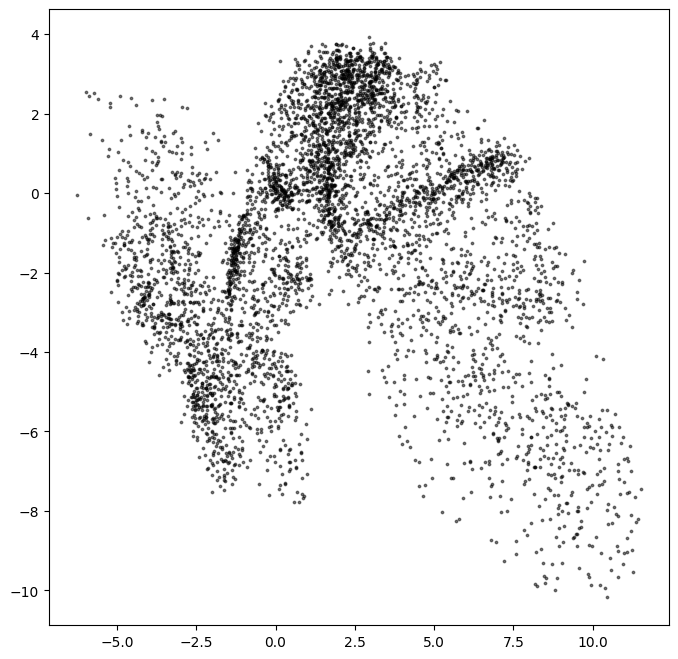

In [11]:
import matplotlib.pyplot as plt 
embeddings = encoder.predict(example_images)

plt.figure(figsize=(8, 8))
plt.scatter(embeddings[:, 0], embeddings[:, 1], c="black", alpha=0.5, s=3)
plt.show()

In [12]:
mins, maxs = np.min(embeddings, axis=0), np.max(embeddings, axis=0)
sample = np.random.uniform(mins, maxs, size=(18, 2))
reconstructions = decoder.predict(sample)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


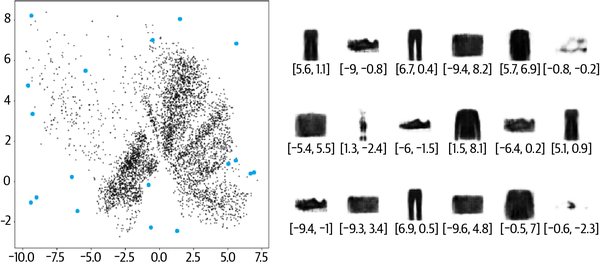